In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '2' # Replace digit with number of desired GPU
#os.environ["JAX_PLATFORMS"] = "cpu"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


%load_ext autoreload

In [2]:
# Basic Library Imports
import jax
import jax.numpy as jnp
from jax import random
from jax import vmap, jit, grad, value_and_grad

from flax import linen as nn
from flax.core import FrozenDict
import optax

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as onp
import copy
import pickle
import pandas as pd

In [ ]:
%autoreload 2
import sys
sys.path.append('../..')
from jaxmix.archs import MLP, MDN, Ensemble
from jaxmix.trainers import MDNTrainer, MSETrainer
from jaxmix.utils import split_data
from jaxmix.data_loaders import BatchedDataset, BootstrapBatchedDataset

from utils import plot_mdn_mixture_elements, plot_mdn_samples, generate_data

In [4]:
key = random.PRNGKey(0)
input_dim = 1
out_dim = 1

## Generating Dataset

In [5]:
## Canonical example for MDN
outputs, inputs = generate_data(10_000)

key, subkey = random.split(key)
n_train = 5_000
n_val = 2_000
train_data, test_data = split_data(subkey, inputs, outputs, n_train, n_val)

train_inputs, train_outputs, train_weights = train_data
test_inputs, test_outputs, test_weights = test_data

In [6]:
print(f"Train inputs shape: {train_inputs.shape}")
print(f"Train outputs shape: {train_outputs.shape}")
print(f"Train weights shape: {train_weights.shape}")
print(f"Test inputs shape: {test_inputs.shape}")
print(f"Test outputs shape: {test_outputs.shape}")
print(f"Test weights shape: {test_weights.shape}")

Train inputs shape: (5000, 1)
Train outputs shape: (5000, 1)
Train weights shape: (5000, 1)
Test inputs shape: (2000, 1)
Test outputs shape: (2000, 1)
Test weights shape: (2000, 1)


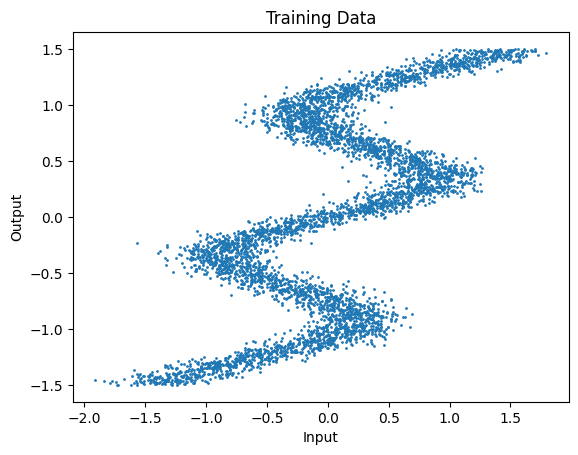

In [7]:
plt.scatter(train_inputs.squeeze(), train_outputs.squeeze(), s=1)
plt.title("Training Data")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()

## Using Mean Square Error (MSE) Loss

In [8]:
key = random.PRNGKey(0)
base_arch = MLP(features=[128, 128, 128, 128, 128, 1])
ensemble_size = 12
arch = Ensemble(base_arch, ensemble_size)

# Use Optax's built-in linear warmup + exponential decay schedule
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0,
            end_value=1e-3,
            transition_steps=1000
        ),
        optax.exponential_decay(
            init_value=1e-3,
            transition_steps=1_000,
            decay_rate=0.9,
            #end_value=5e-5
        ),
    ],
    boundaries=[1000]
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.01),  # Adaptively clip gradients with threshold of 1%
    optax.adamw(learning_rate=lr, weight_decay=1e-1)
)
init_batch = (train_inputs, train_outputs, train_weights)
key, subkey = random.split(key)
model = MSETrainer(arch, init_batch, key=subkey, optimizer=optimizer, normalize_inputs=True, normalize_outputs=True)
print(model.tabulate())


                                         Ensemble Summary                                         
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module   ┃ inputs            ┃ outputs            ┃ params                      ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│              │ Ensemble │ float32[5000,1]   │ float32[12,5000,1] │                             │
├──────────────┼──────────┼───────────────────┼────────────────────┼─────────────────────────────┤
│ arch         │ MLP      │ float32[5000,1]   │ float32[5000,1]    │                             │
├──────────────┼──────────┼───────────────────┼────────────────────┼─────────────────────────────┤
│ arch/Dense_0 │ Dense    │ float32[5000,1]   │ float32[5000,128]  │ bias: float32[12,128]       │
│              │          │                   │                    │ kernel: float32[12,1,128]   │
│        

In [9]:
key, subkey = random.split(key)
train_loader = BatchedDataset(train_data, subkey, batch_size=256)
model.train(train_loader, nIter=30_000)

# use the lines below to run with data bootstrapping (aka bagging)
# train_loader = BootstrapBatchedDataset(train_data, subkey, num_bootstraps=ensemble_size, batch_size=128)
# model.train(train_loader, nIter=30_000, apply_kwargs={'backbone_kwargs': {'tile_inputs': False}})

100%|██████████| 30000/30000 [00:22<00:00, 1351.88it/s, loss=0.65001255, grad_norm=0.031858146]


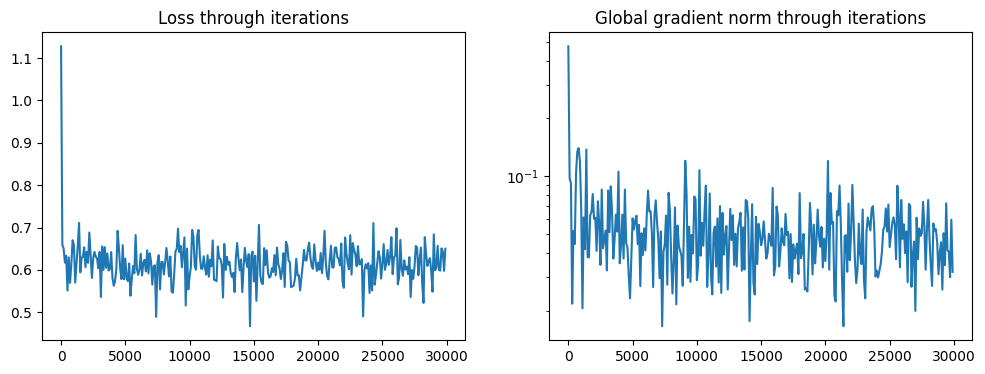

In [10]:
model.plot_logs()

In [11]:
pred = model.apply(model.params, test_inputs)

pred.shape

(12, 2000, 1)

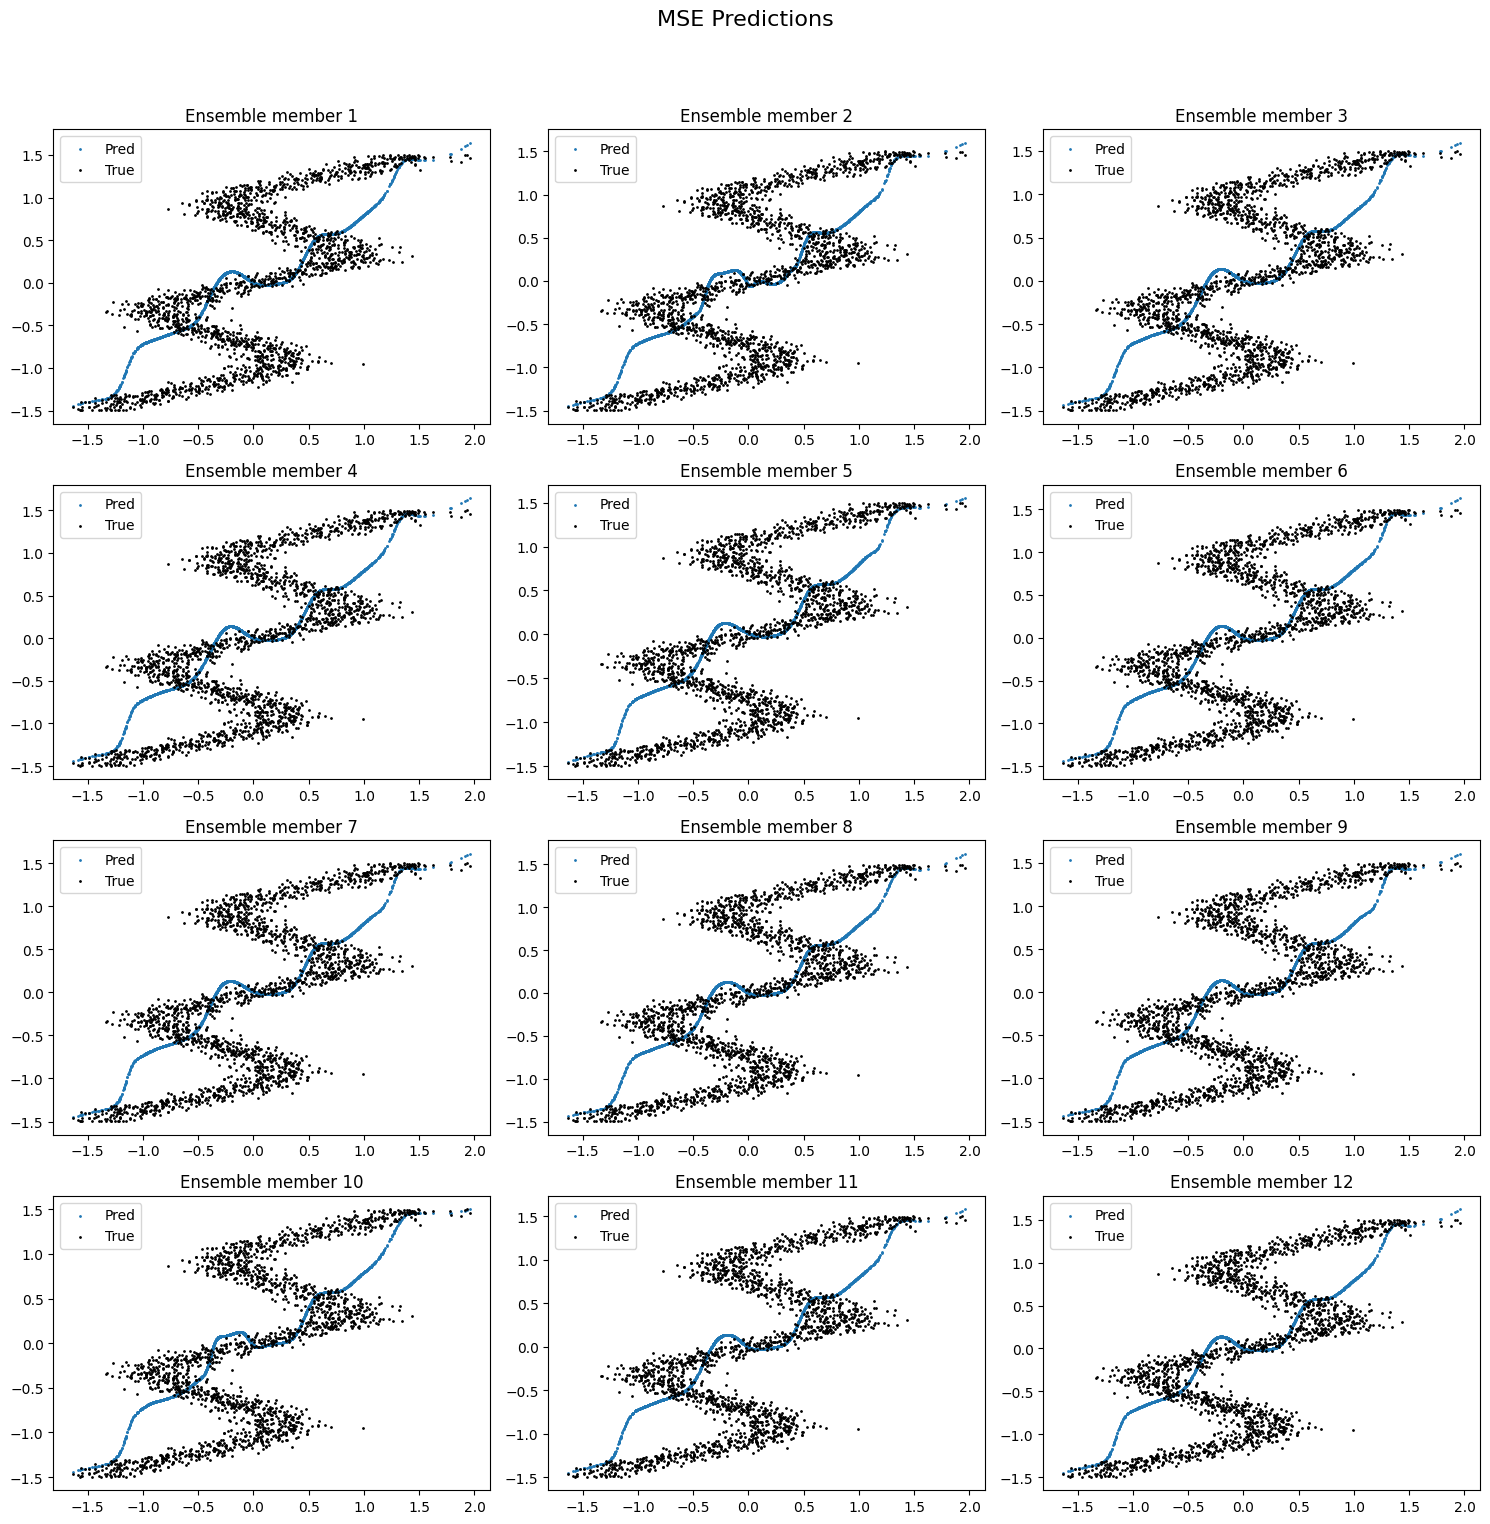

In [12]:
num_cols = 3
num_rows = (ensemble_size + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows), squeeze=False)
fig.suptitle("MSE Predictions", fontsize=16)
for i in range(ensemble_size):
    row = i // num_cols
    col = i % num_cols
    ax = axes[row, col]
    ax.scatter(test_inputs.squeeze(), pred[i].squeeze(), s=1, label='Pred')
    ax.scatter(test_inputs.squeeze(), test_outputs.squeeze(), s=1, label='True', c='black')
    ax.set_title(f'Ensemble member {i+1}')
    ax.legend()
# Hide any unused subplots
for j in range(ensemble_size, num_rows * num_cols):
    fig.delaxes(axes[j // num_cols, j % num_cols])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Using Mixture Density Networks (MDNs)

In [13]:
key = random.PRNGKey(0)
base_arch = MLP(features=[128, 128, 128, 128, 128])# base_arch_train = MLP(features=[32, 32, 32, 32, 32])
# base_arch_prior = MLP(features=[16, 16, 16, 16, 32])
ensemble_size = 12
backbone_arch = Ensemble(base_arch, ensemble_size)
num_mixtures = 9
MDN_arch = MDN(num_mixtures=num_mixtures, num_output_dims=out_dim, backbone=backbone_arch, ensemble_size=ensemble_size)

# Use Optax's built-in linear warmup + exponential decay schedule
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0,
            end_value=1e-3,
            transition_steps=1000
        ),
        optax.exponential_decay(
            init_value=1e-3,
            transition_steps=1_000,
            decay_rate=0.9,
            #end_value=5e-5
        ),
    ],
    boundaries=[1000]
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.01),  # Adaptively clip gradients with threshold of 1%
    optax.adamw(learning_rate=lr, weight_decay=1e-1)
)
init_batch = (train_inputs, train_outputs, train_weights)
key, subkey = random.split(key)
model = MDNTrainer(MDN_arch, init_batch, key=subkey, optimizer=optimizer, masked_param_names='arch_prior', normalize_inputs=True, normalize_outputs=False)
print(model.tabulate())


                                                      MDN Summary                                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path                  ┃ module       ┃ inputs                 ┃ outputs                ┃ params                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│                       │ MDN          │ float32[5000,1]        │ - float32[12,5000,9,1] │                             │
│                       │              │                        │ - float32[12,5000,9,1] │                             │
│                       │              │                        │ - float32[12,5000,9,1] │                             │
├───────────────────────┼──────────────┼────────────────────────┼────────────────────────┼─────────────────────────────┤
│ backbone              │ Ensem

In [14]:
key, subkey = random.split(key)
train_loader = BatchedDataset(train_data, subkey, batch_size=256)
model.train(train_loader, nIter=30_000)

# use the lines below to run with data bootstrapping (aka bagging)
# train_loader = BootstrapBatchedDataset(train_data, subkey, num_bootstraps=ensemble_size, batch_size=128)
# model.train(train_loader, nIter=30_000, apply_kwargs={'backbone_kwargs': {'tile_inputs': False}})

100%|██████████| 30000/30000 [00:24<00:00, 1222.19it/s, loss=0.0008644822, grad_norm=3.5263262]  


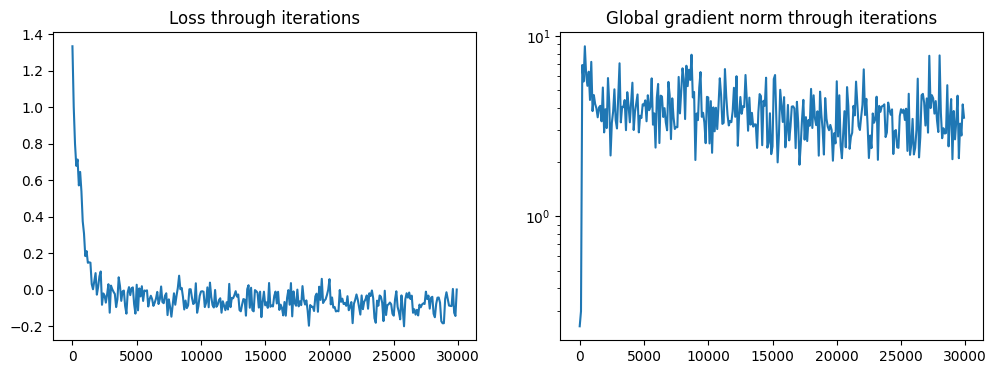

In [15]:
model.plot_logs()

In [16]:
pred = model.apply(model.params, test_inputs)
mixture_logit_weights, mixture_means, mixture_variances = pred

per_element_nll = model.per_element_loss(pred, test_outputs)

mixture_logit_weights.shape, mixture_means.shape, mixture_variances.shape, per_element_nll.shape

((12, 2000, 9, 1), (12, 2000, 9, 1), (12, 2000, 9, 1), (12, 2000, 1))

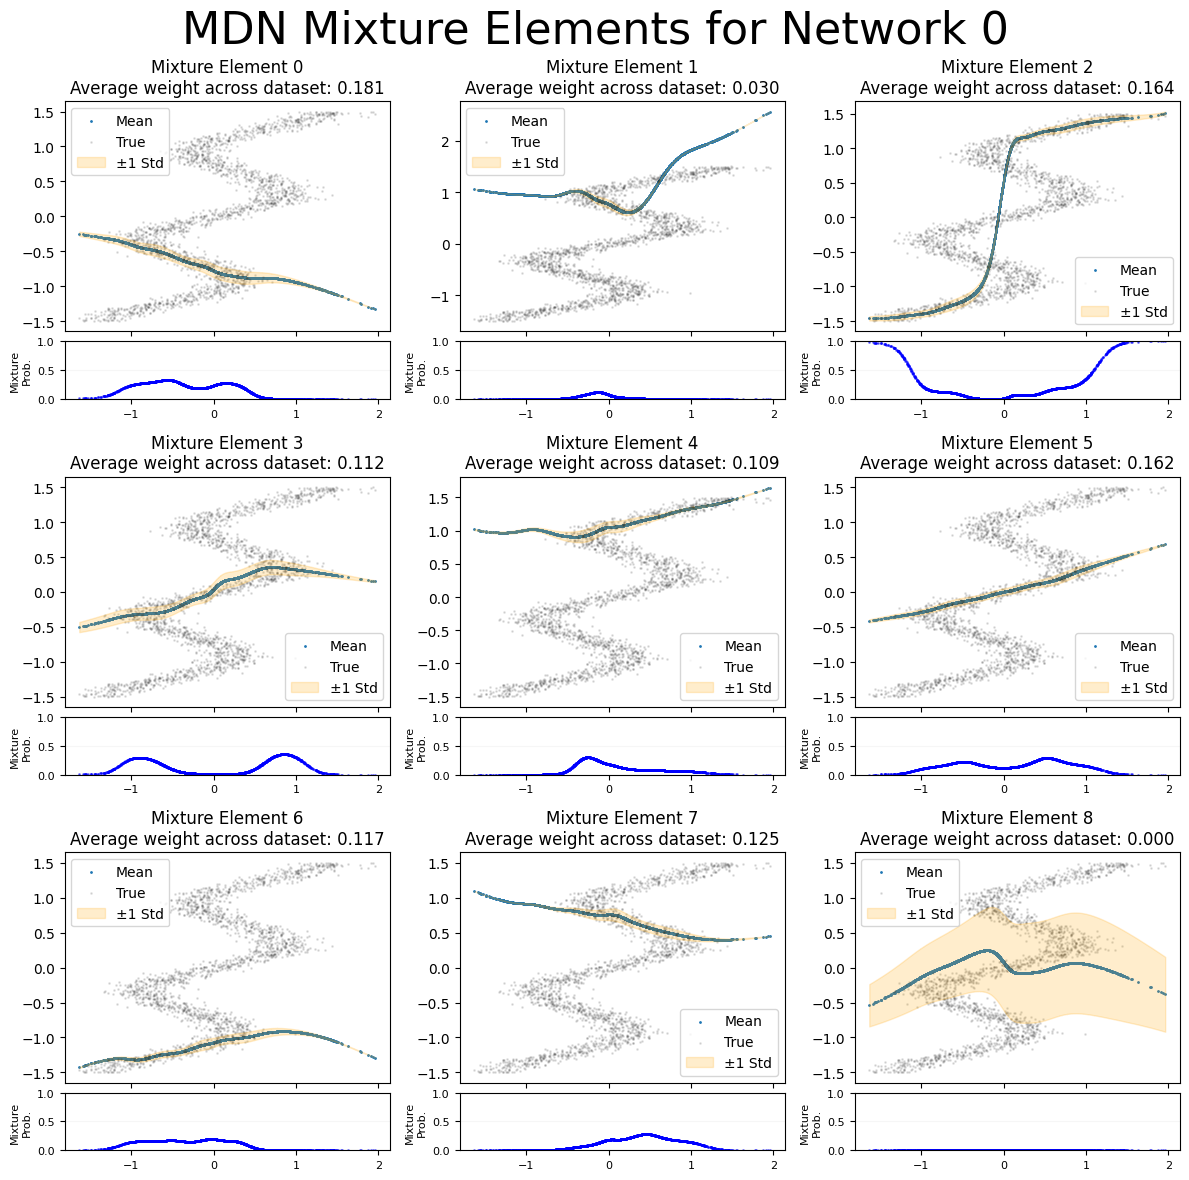

In [17]:
plot_mdn_mixture_elements(model, test_inputs, test_outputs, net_id=0)

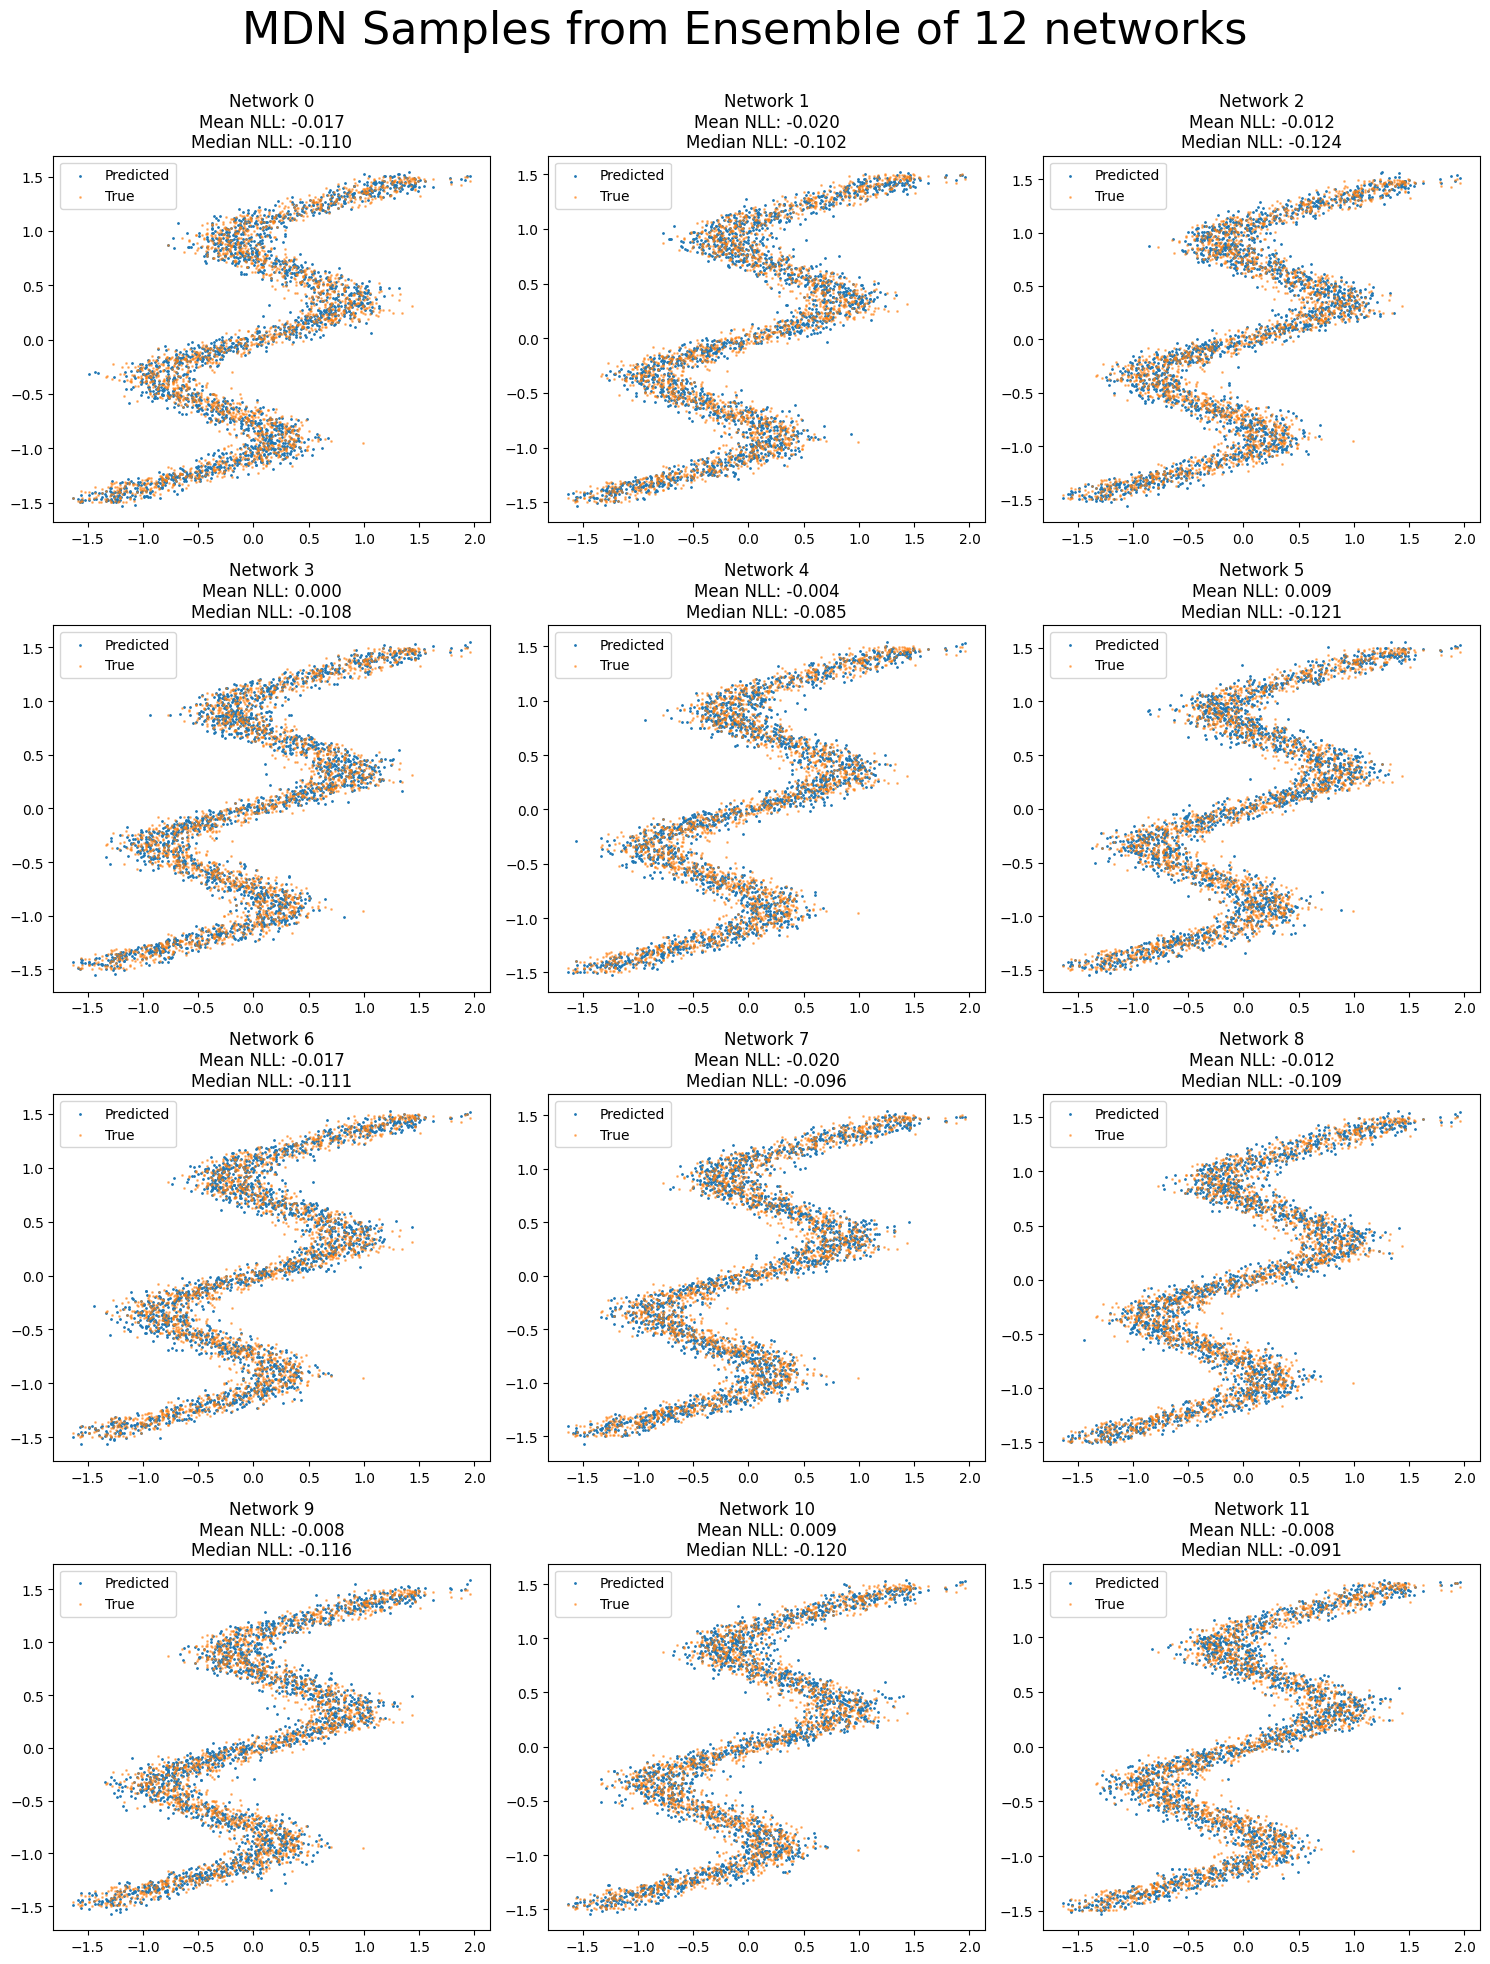

In [18]:
plot_mdn_samples(model, test_inputs, test_outputs)

## Using Conditional Flow Matching (CFM)

In [ ]:
%autoreload 2
from jaxmix.data_loaders import FlowMatchingDataset
from jaxmix.trainers import ConditionalFlowMatchingTrainer
from utils import plot_flow_matching_samples

In [20]:
base_arch = MLP(features=[128, 128, 128, 128, 128, out_dim])
ensemble_size = 12
arch = Ensemble(base_arch, ensemble_size)

# Use Optax's built-in linear warmup + exponential decay schedule
peak_lr = 1e-3
warmup_steps = 1000
lr = optax.join_schedules(
    schedules=[
        optax.linear_schedule(
            init_value=0.0,
            end_value=peak_lr,
            transition_steps=warmup_steps
        ),
        optax.exponential_decay(
            init_value=peak_lr,
            transition_steps=1_000,
            decay_rate=0.9,
            #end_value=5e-5
        ),
    ],
    boundaries=[warmup_steps]
)
optimizer = optax.chain(
    optax.adaptive_grad_clip(0.01),  # Adaptively clip gradients with threshold of 1%
    optax.adamw(learning_rate=lr, weight_decay=1e-2)
)
key, subkey = random.split(key)
data_loader = FlowMatchingDataset(train_data, subkey, batch_size=None, sigma=0.0)
init_batch = next(iter(data_loader))
key, subkey = random.split(key)
model = ConditionalFlowMatchingTrainer(arch, init_batch, key=subkey, optimizer=optimizer, normalize_inputs=True, normalize_outputs=True, ensemble_size=ensemble_size)
print(model.tabulate())


                                         Ensemble Summary                                         
┏━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path         ┃ module   ┃ inputs            ┃ outputs            ┃ params                      ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│              │ Ensemble │ float32[5000,3]   │ float32[12,5000,1] │                             │
├──────────────┼──────────┼───────────────────┼────────────────────┼─────────────────────────────┤
│ arch         │ MLP      │ float32[5000,3]   │ float32[5000,1]    │                             │
├──────────────┼──────────┼───────────────────┼────────────────────┼─────────────────────────────┤
│ arch/Dense_0 │ Dense    │ float32[5000,3]   │ float32[5000,128]  │ bias: float32[12,128]       │
│              │          │                   │                    │ kernel: float32[12,3,128]   │
│        

In [21]:
key, subkey = random.split(key)
train_loader = FlowMatchingDataset(train_data, subkey, batch_size=256, sigma=0.0)
model.train(train_loader, nIter=30_000)

100%|██████████| 30000/30000 [00:22<00:00, 1320.48it/s, loss=0.51764727, grad_norm=0.10919325] 


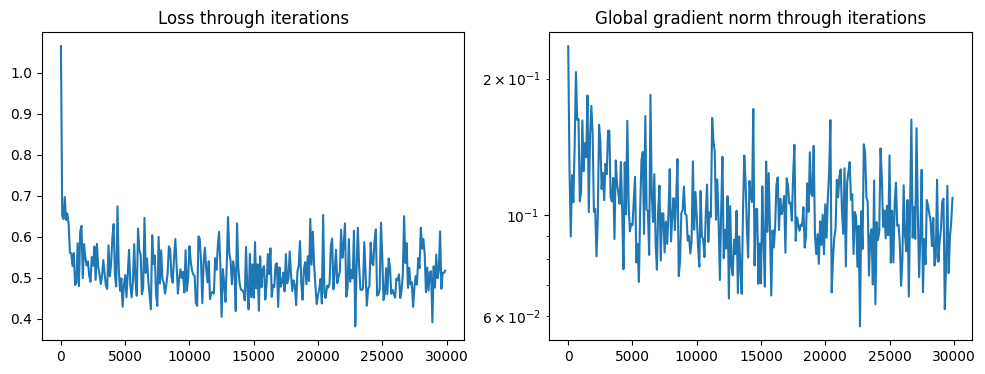

In [22]:
model.plot_logs()

Computing NLL: 100%|██████████| 10000/10000 [01:56<00:00, 85.57it/s]


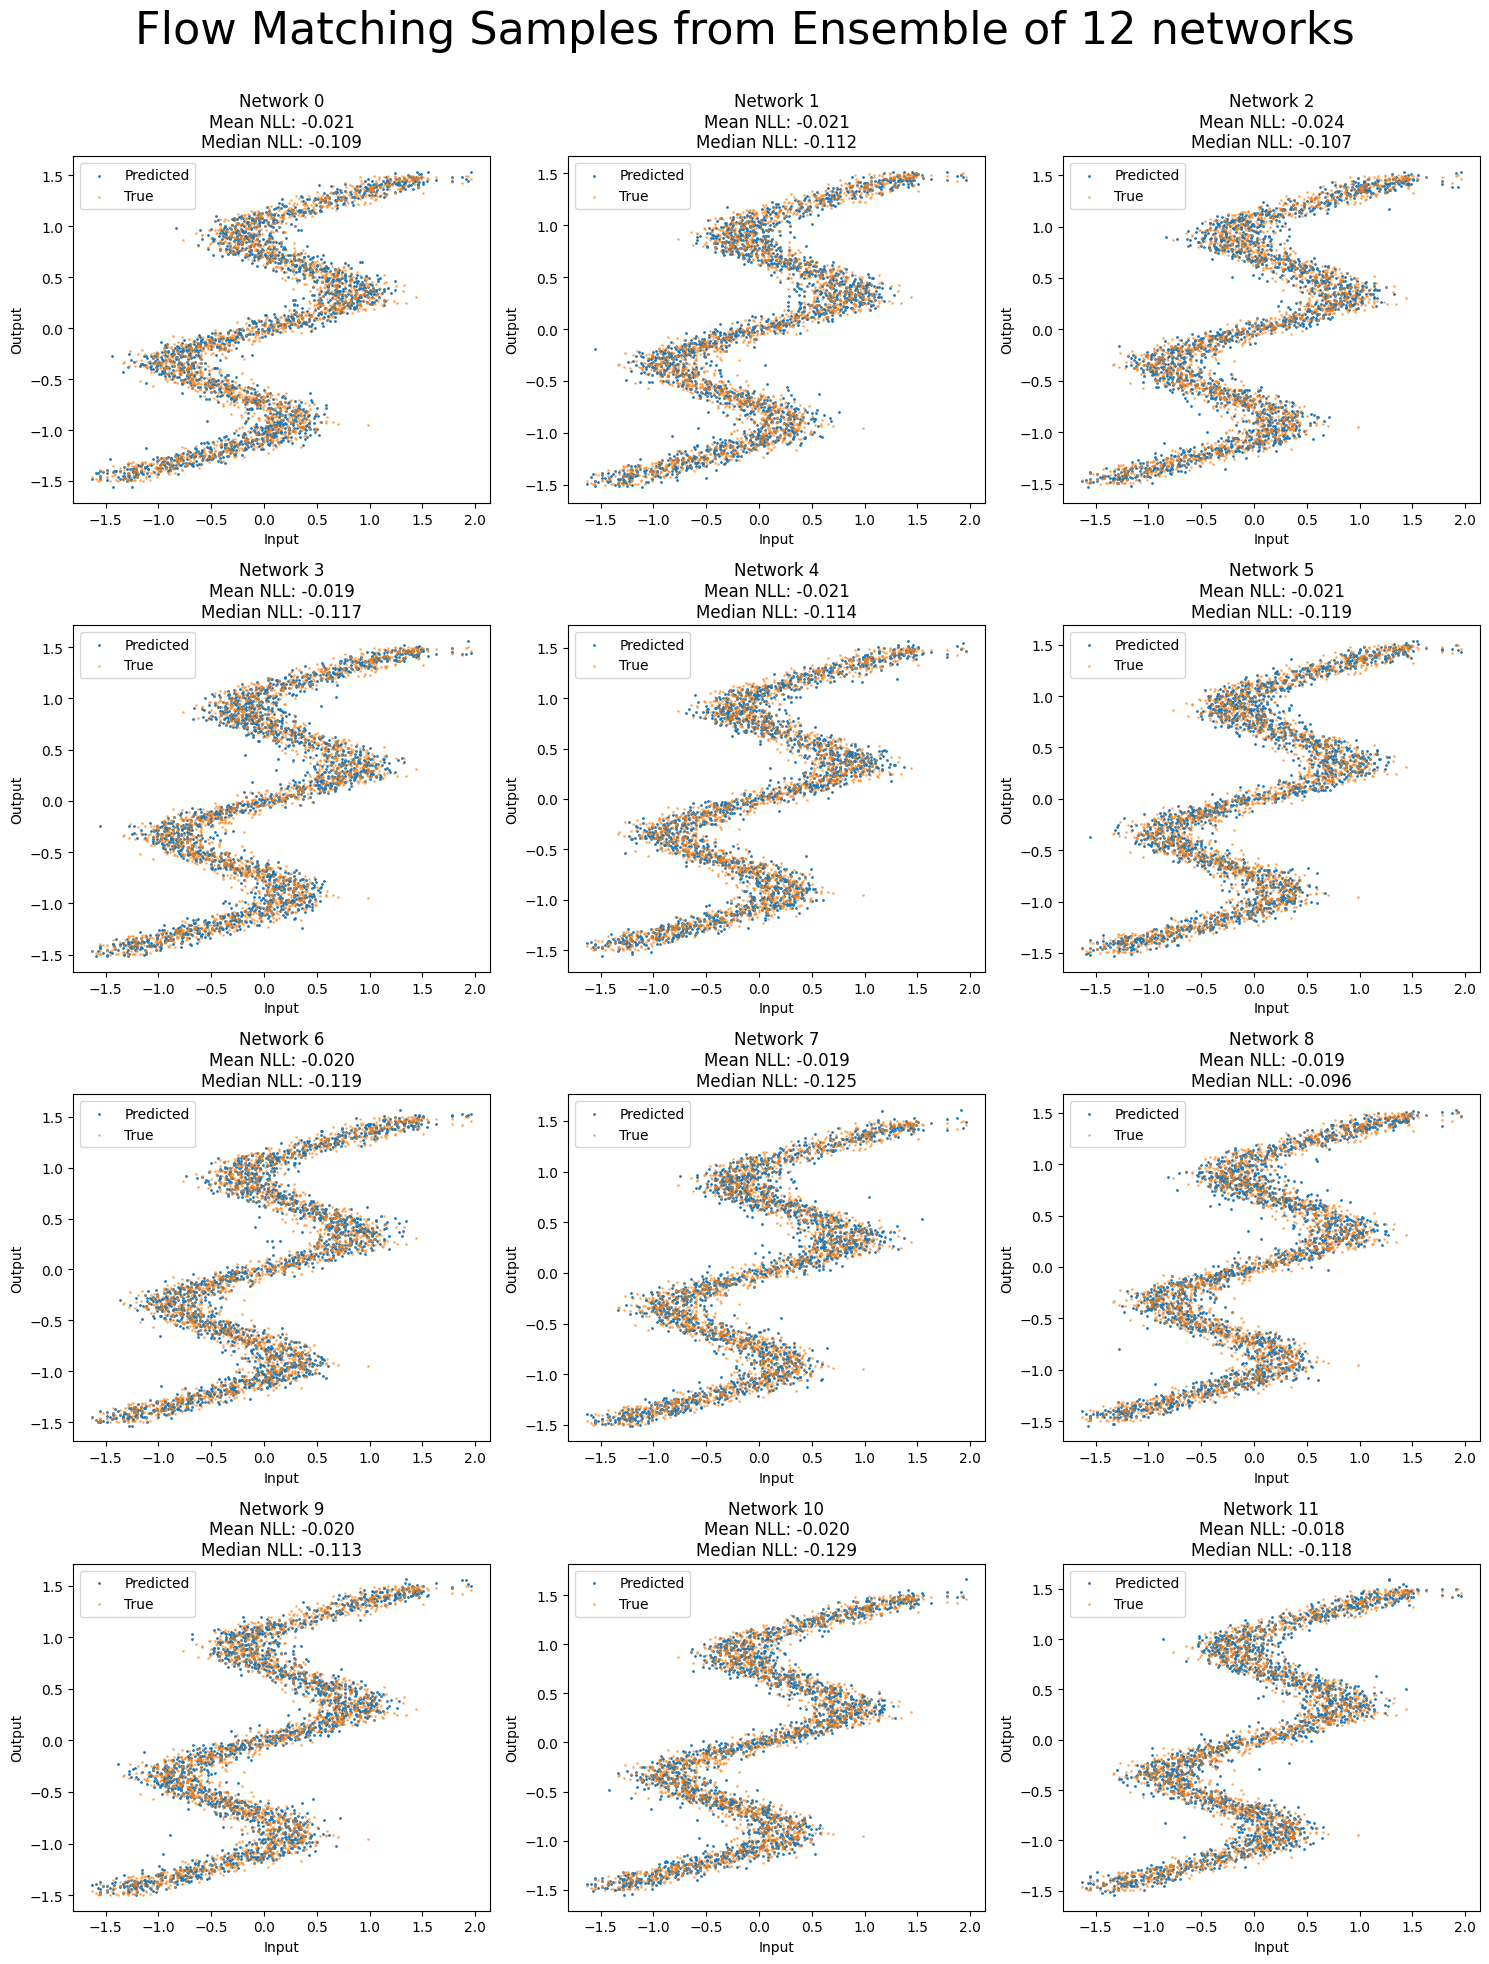

In [23]:
plot_flow_matching_samples(model, subkey, test_inputs, test_outputs, ensemble_size)